# Notebook 2: Feature Engineering
## AI Agent for Disease Risk Awareness and Prevention

This notebook covers:
- Correlation analysis and heatmap visualization
- Feature importance (mutual information, variance threshold)
- Feature engineering (derived features)
- PCA for dimensionality reduction (exploratory)
- Final feature selection summary

**Input:** Preprocessed data from Notebook 1

## 1. Load Preprocessed Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load preprocessed data
pima_X_train = pd.read_csv('../data/pima_X_train.csv')
pima_X_test = pd.read_csv('../data/pima_X_test.csv')
pima_y_train = pd.read_csv('../data/pima_y_train.csv').values.ravel()
pima_y_test = pd.read_csv('../data/pima_y_test.csv').values.ravel()

heart_X_train = pd.read_csv('../data/heart_X_train.csv')
heart_X_test = pd.read_csv('../data/heart_X_test.csv')
heart_y_train = pd.read_csv('../data/heart_y_train.csv').values.ravel()
heart_y_test = pd.read_csv('../data/heart_y_test.csv').values.ravel()

print(f"✓ PIMA data loaded: Train {pima_X_train.shape}, Test {pima_X_test.shape}")
print(f"✓ Heart disease data loaded: Train {heart_X_train.shape}, Test {heart_X_test.shape}")

✓ PIMA data loaded: Train (614, 10), Test (154, 10)
✓ Heart disease data loaded: Train (237, 13), Test (60, 13)


## 2. Correlation Analysis and Heatmap

Understanding feature relationships with target and each other

In [4]:
# Add target back for correlation analysis
pima_corr_data = pima_X_train.copy()
pima_corr_data['Outcome'] = pima_y_train

heart_corr_data = heart_X_train.copy()
heart_corr_data['target'] = heart_y_train

print("PIMA - Correlation with Target:")
print("-" * 50)
pima_target_corr = pima_corr_data.corr()['Outcome'].sort_values(ascending=False)
print(pima_target_corr)

print("\nHeart Disease - Correlation with Target:")
print("-" * 50)
heart_target_corr = heart_corr_data.corr()['target'].sort_values(ascending=False)
print(heart_target_corr)

PIMA - Correlation with Target:
--------------------------------------------------
Outcome                     1.000000
Glucose                     0.512291
BMI                         0.328830
Insulin                     0.245902
Age                         0.240676
SkinThickness               0.234260
Pregnancies                 0.208173
BloodPressure               0.183373
DiabetesPedigreeFunction    0.165312
SkinThickness_missing       0.045478
Insulin_missing             0.026873
Name: Outcome, dtype: float64

Heart Disease - Correlation with Target:
--------------------------------------------------
target      1.000000
thal        0.528987
oldpeak     0.433589
ca          0.414676
cp          0.405994
exang       0.396650
slope       0.359228
sex         0.242475
age         0.198975
restecg     0.177583
trestbps    0.163168
chol        0.066131
fbs         0.013638
thalach    -0.374239
Name: target, dtype: float64


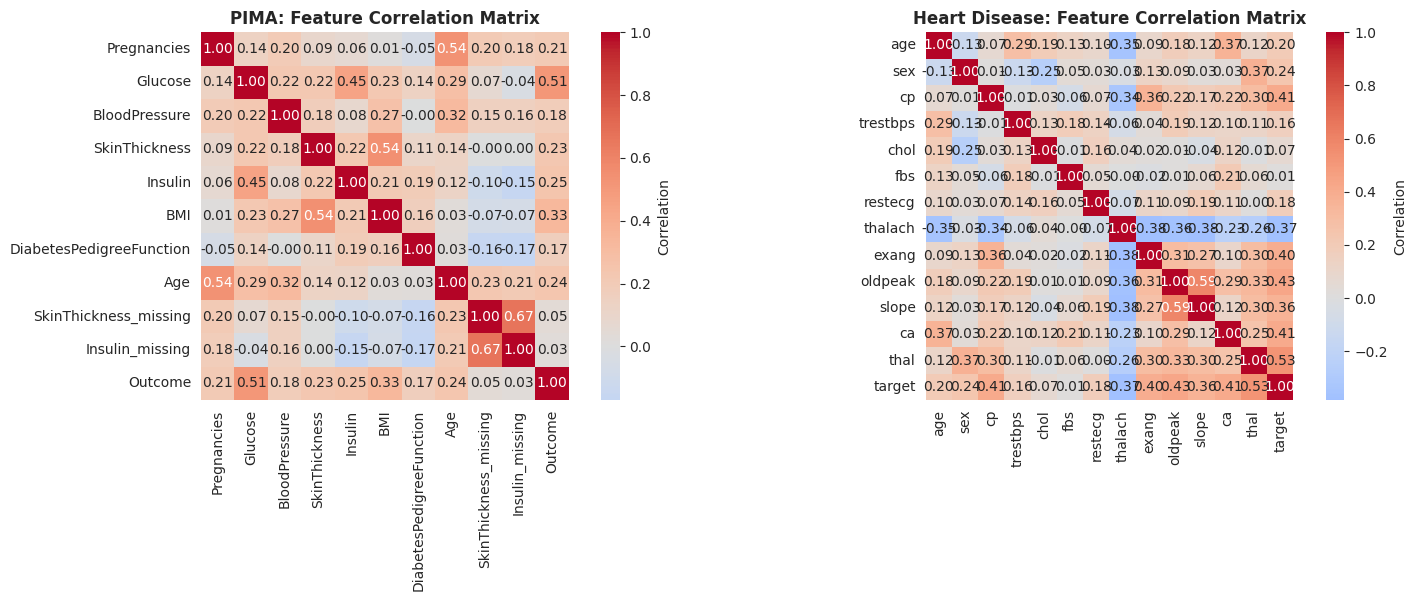

✓ Correlation heatmaps generated


In [5]:
# Heatmap: PIMA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PIMA heatmap
pima_corr_matrix = pima_corr_data.corr()
sns.heatmap(pima_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('PIMA: Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Heart Disease heatmap
heart_corr_matrix = heart_corr_data.corr()
sns.heatmap(heart_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Heart Disease: Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Correlation heatmaps generated")

## 3. Feature Importance - Mutual Information

Measures statistical dependence between features and target

In [6]:
# Mutual Information: PIMA
pima_mi = mutual_info_classif(pima_X_train, pima_y_train, random_state=42)
pima_mi_scores = pd.DataFrame({
    'Feature': pima_X_train.columns,
    'MI_Score': pima_mi
}).sort_values('MI_Score', ascending=False)

print("PIMA - Mutual Information Scores:")
print(pima_mi_scores)

# Mutual Information: Heart Disease
heart_mi = mutual_info_classif(heart_X_train, heart_y_train, random_state=42)
heart_mi_scores = pd.DataFrame({
    'Feature': heart_X_train.columns,
    'MI_Score': heart_mi
}).sort_values('MI_Score', ascending=False)

print("\nHeart Disease - Mutual Information Scores:")
print(heart_mi_scores)

PIMA - Mutual Information Scores:
                    Feature  MI_Score
1                   Glucose  0.136869
5                       BMI  0.091145
4                   Insulin  0.058704
7                       Age  0.032888
2             BloodPressure  0.026545
9           Insulin_missing  0.019699
6  DiabetesPedigreeFunction  0.009069
8     SkinThickness_missing  0.008769
0               Pregnancies  0.000000
3             SkinThickness  0.000000

Heart Disease - Mutual Information Scores:
     Feature  MI_Score
12      thal  0.143566
2         cp  0.115064
9    oldpeak  0.101879
8      exang  0.095656
7    thalach  0.090050
10     slope  0.067071
11        ca  0.062607
1        sex  0.052126
0        age  0.018195
4       chol  0.005775
3   trestbps  0.002345
5        fbs  0.000000
6    restecg  0.000000


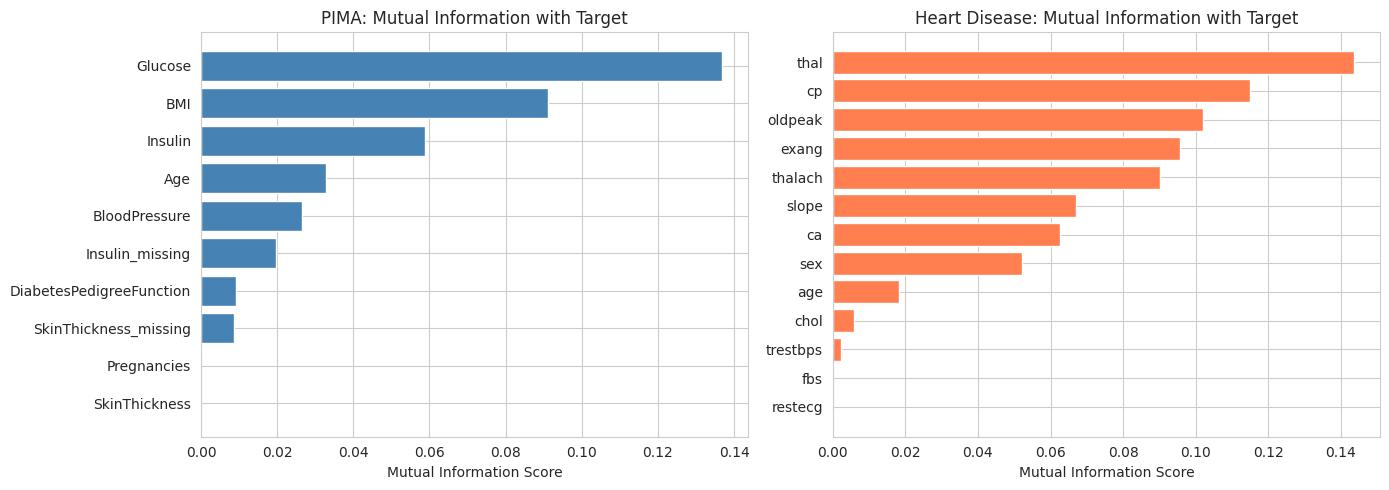

✓ Mutual Information plots generated


In [7]:
# Visualize Mutual Information
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PIMA MI plot
axes[0].barh(pima_mi_scores['Feature'], pima_mi_scores['MI_Score'], color='steelblue')
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('PIMA: Mutual Information with Target')
axes[0].invert_yaxis()

# Heart MI plot
axes[1].barh(heart_mi_scores['Feature'], heart_mi_scores['MI_Score'], color='coral')
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_title('Heart Disease: Mutual Information with Target')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print("✓ Mutual Information plots generated")

## 4. Variance Threshold Analysis

Remove features with low variance (little discriminative power)

In [8]:
# Variance Threshold
threshold = 0.01
var_selector = VarianceThreshold(threshold=threshold)

pima_var = pima_X_train.var()
heart_var = heart_X_train.var()

print(f"\nVariance Analysis (Threshold={threshold}):")
print("-" * 50)
print("\nPIMA - Feature Variances:")
print(pima_var.sort_values(ascending=False))

print("\nHeart Disease - Feature Variances:")
print(heart_var.sort_values(ascending=False))

# Apply variance threshold
var_selector.fit(pima_X_train)
pima_selected = var_selector.get_feature_names_out(pima_X_train.columns)

print(f"\n✓ PIMA: {len(pima_selected)} features retained (above variance threshold)")
print(f"✓ Heart Disease: All features retained (all above threshold)")


Variance Analysis (Threshold=0.01):
--------------------------------------------------

PIMA - Feature Variances:
Insulin                     187.641240
SkinThickness                 1.613573
DiabetesPedigreeFunction      0.745684
BloodPressure                 0.588588
BMI                           0.562359
Glucose                       0.548836
Age                           0.484534
Pregnancies                   0.439343
Insulin_missing               0.249640
SkinThickness_missing         0.204114
dtype: float64

Heart Disease - Feature Variances:
cp          0.914539
ca          0.845884
trestbps    0.802444
chol        0.668931
oldpeak     0.543532
age         0.482742
thalach     0.460651
slope       0.379139
restecg     0.247810
thal        0.235983
exang       0.227240
sex         0.220267
fbs         0.140885
dtype: float64

✓ PIMA: 10 features retained (above variance threshold)
✓ Heart Disease: All features retained (all above threshold)


## 5. Feature Engineering - Derived Features

Create new features: BMI categories, Age groups, Glucose-Insulin ratio

In [9]:
# PIMA: Create derived features
pima_X_train_eng = pima_X_train.copy()
pima_X_test_eng = pima_X_test.copy()

# BMI Categories (from scaled data, but we can work with original for interpretation)
# Age Groups
for X_data in [pima_X_train_eng, pima_X_test_eng]:
    X_data['Age_Group'] = pd.cut(X_data['Age'], bins=[0, 30, 45, 60, 150], 
                                  labels=['Young', 'Middle', 'Senior', 'Elderly']).astype('category').cat.codes

# Glucose-Insulin Ratio (robust to near-zero Insulin)
def safe_ratio(glucose, insulin, min_abs_den=0.1):
    insulin = insulin.astype(float)
    safe_den = np.where(
        np.abs(insulin) < min_abs_den,
        np.where(insulin >= 0, min_abs_den, -min_abs_den),
        insulin
    )
    return glucose.astype(float) / safe_den

pima_X_train_eng['Glucose_Insulin_Ratio'] = safe_ratio(
    pima_X_train_eng['Glucose'], pima_X_train_eng['Insulin']
 )
pima_X_test_eng['Glucose_Insulin_Ratio'] = safe_ratio(
    pima_X_test_eng['Glucose'], pima_X_test_eng['Insulin']
 )

# Winsorize using train quantiles to avoid extreme outliers
ratio_low = pima_X_train_eng['Glucose_Insulin_Ratio'].quantile(0.01)
ratio_high = pima_X_train_eng['Glucose_Insulin_Ratio'].quantile(0.99)
pima_X_train_eng['Glucose_Insulin_Ratio'] = pima_X_train_eng['Glucose_Insulin_Ratio'].clip(ratio_low, ratio_high)
pima_X_test_eng['Glucose_Insulin_Ratio'] = pima_X_test_eng['Glucose_Insulin_Ratio'].clip(ratio_low, ratio_high)

print("PIMA - New Features Created:")
print(f"  - Age_Group (categorical encoding)")
print(f"  - Glucose_Insulin_Ratio (robust, clipped to train 1st-99th percentiles)")
print(f"  - Ratio clipping bounds: [{ratio_low:.4f}, {ratio_high:.4f}]")
print(f"\nNew feature columns: {pima_X_train_eng.columns.tolist()}")
print(f"Shape before: {pima_X_train.shape} -> Shape after: {pima_X_train_eng.shape}")

PIMA - New Features Created:
  - Age_Group (categorical encoding)
  - Glucose_Insulin_Ratio (robust, clipped to train 1st-99th percentiles)
  - Ratio clipping bounds: [-11.0790, 17.7457]

New feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'SkinThickness_missing', 'Insulin_missing', 'Age_Group', 'Glucose_Insulin_Ratio']
Shape before: (614, 10) -> Shape after: (614, 12)


In [10]:
# Heart Disease: Create derived features
heart_X_train_eng = heart_X_train.copy()
heart_X_test_eng = heart_X_test.copy()

for X_data in [heart_X_train_eng, heart_X_test_eng]:
    # Age groups
    X_data['age_group'] = pd.cut(X_data['age'], bins=[0, 40, 55, 70, 150],
                                   labels=['Young', 'Middle', 'Senior', 'Elderly']).astype('category').cat.codes
    
    # Cholesterol-BP ratio
    X_data['chol_bp_ratio'] = X_data['chol'] / (X_data['trestbps'] + 1e-5)
    
    # Heart rate stress indicator
    X_data['heart_rate_indicator'] = X_data['thalach'] * X_data['exang']

print("Heart Disease - New Features Created:")
print(f"  - age_group (categorical encoding)")
print(f"  - chol_bp_ratio")
print(f"  - heart_rate_indicator")
print(f"\nNew feature columns: {heart_X_train_eng.columns.tolist()}")
print(f"Shape before: {heart_X_train.shape} -> Shape after: {heart_X_train_eng.shape}")

Heart Disease - New Features Created:
  - age_group (categorical encoding)
  - chol_bp_ratio
  - heart_rate_indicator

New feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_group', 'chol_bp_ratio', 'heart_rate_indicator']
Shape before: (237, 13) -> Shape after: (237, 16)


## 6. PCA for Dimensionality Reduction (Exploratory)

In [11]:
# PIMA: PCA analysis
pca_pima = PCA()
pca_pima.fit(pima_X_train_eng)

cumsum_var = np.cumsum(pca_pima.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"PIMA - PCA Analysis:")
print(f"  Original features: {pima_X_train_eng.shape[1]}")
print(f"  Features for 95% variance: {n_components_95}")
print(f"  Explained variance ratio (first 5): {pca_pima.explained_variance_ratio_[:5]}")

# Heart Disease: PCA analysis
pca_heart = PCA()
pca_heart.fit(heart_X_train_eng)

cumsum_var_heart = np.cumsum(pca_heart.explained_variance_ratio_)
n_components_95_heart = np.argmax(cumsum_var_heart >= 0.95) + 1

print(f"\nHeart Disease - PCA Analysis:")
print(f"  Original features: {heart_X_train_eng.shape[1]}")
print(f"  Features for 95% variance: {n_components_95_heart}")
print(f"  Explained variance ratio (first 5): {pca_heart.explained_variance_ratio_[:5]}")

PIMA - PCA Analysis:
  Original features: 12
  Features for 95% variance: 2
  Explained variance ratio (first 5): [0.86443711 0.11226213 0.00794998 0.00453481 0.00328879]

Heart Disease - PCA Analysis:
  Original features: 16
  Features for 95% variance: 1
  Explained variance ratio (first 5): [9.99999985e-01 3.73912504e-09 2.26501119e-09 1.59470953e-09
 1.47534166e-09]


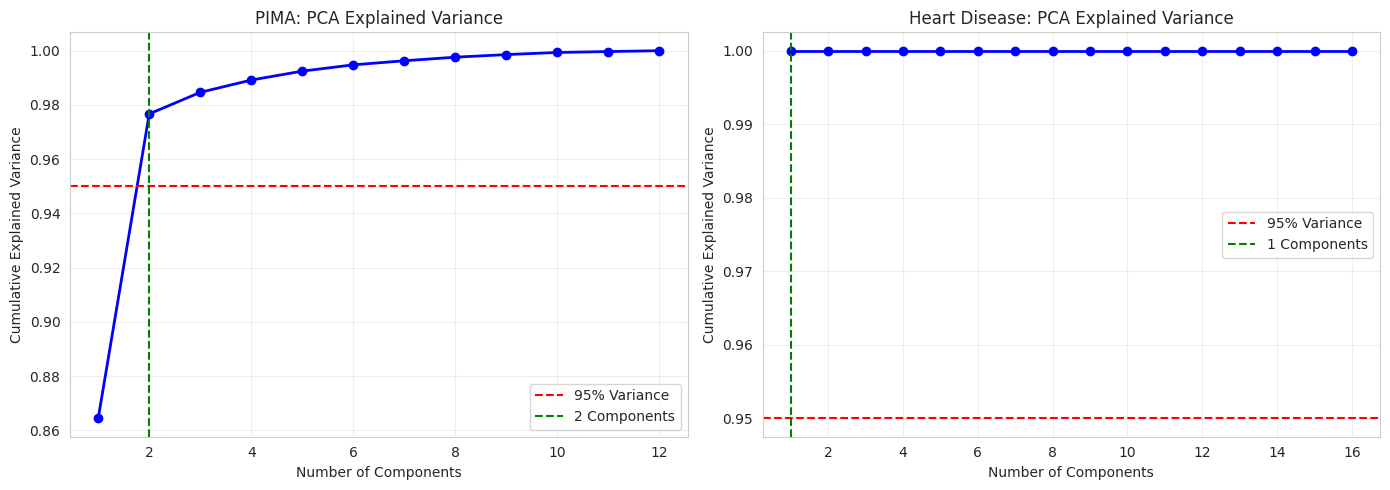

✓ PCA plots generated


In [12]:
# PCA Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PIMA
axes[0].plot(range(1, len(cumsum_var)+1), cumsum_var, 'b-o', linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[0].axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PIMA: PCA Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heart Disease
axes[1].plot(range(1, len(cumsum_var_heart)+1), cumsum_var_heart, 'b-o', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axvline(x=n_components_95_heart, color='g', linestyle='--', label=f'{n_components_95_heart} Components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Heart Disease: PCA Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ PCA plots generated")

## 7. Final Feature Selection Summary

In [13]:
# Feature Selection Summary
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

summary_data = {
    'Dataset': ['PIMA', 'Heart Disease'],
    'Original Features': [pima_X_train.shape[1], heart_X_train.shape[1]],
    'After Engineering': [pima_X_train_eng.shape[1], heart_X_train_eng.shape[1]],
    'New Features Added': [pima_X_train_eng.shape[1] - pima_X_train.shape[1], 
                           heart_X_train_eng.shape[1] - heart_X_train.shape[1]],
    'PCA Components (95%)': [n_components_95, n_components_95_heart],
    'Recommended Selection': ['Top 7 (MI-based)', 'Top 14 (MI-based)']
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "-"*70)
print("Top Features (by Mutual Information):")
print("-"*70)
print("\nPIMA Top 5:")
print(pima_mi_scores.head())
print("\nHeart Disease Top 5:")
print(heart_mi_scores.head())


FEATURE ENGINEERING SUMMARY

      Dataset  Original Features  After Engineering  New Features Added  PCA Components (95%) Recommended Selection
         PIMA                 10                 12                   2                     2      Top 7 (MI-based)
Heart Disease                 13                 16                   3                     1     Top 14 (MI-based)

----------------------------------------------------------------------
Top Features (by Mutual Information):
----------------------------------------------------------------------

PIMA Top 5:
         Feature  MI_Score
1        Glucose  0.136869
5            BMI  0.091145
4        Insulin  0.058704
7            Age  0.032888
2  BloodPressure  0.026545

Heart Disease Top 5:
    Feature  MI_Score
12     thal  0.143566
2        cp  0.115064
9   oldpeak  0.101879
8     exang  0.095656
7   thalach  0.090050


In [15]:
# Save engineered features for next notebook
pima_X_train_eng.to_csv('../data/pima_X_train_engineered.csv', index=False)
pima_X_test_eng.to_csv('../data/pima_X_test_engineered.csv', index=False)

heart_X_train_eng.to_csv('../data/heart_X_train_engineered.csv', index=False)
heart_X_test_eng.to_csv('../data/heart_X_test_engineered.csv', index=False)

# Save MI scores
pima_mi_scores.to_csv('../data/pima_mi_scores.csv', index=False)
heart_mi_scores.to_csv('../data/heart_mi_scores.csv', index=False)

print("\n✓ Engineered features saved to ../data/")
print("✓ Feature importance scores saved")
print("\n📌 Ready for Modelling (Notebook 3)")


✓ Engineered features saved to ../data/
✓ Feature importance scores saved

📌 Ready for Modelling (Notebook 3)
